## Image processing - food classifier

### Part I - Baseline Evaluation

Using our own collected data as the input to the classification model. Compare the results versus the results from the Food-101 dataset

First test if the model correctly loaded, and predict example image

Model initialized, using device: cuda


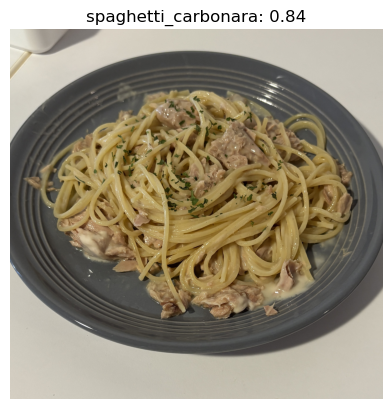

In [1]:
import shutil
import sys
sys.path.insert(0, './src')
from models.classifier import FoodClassifier
from project_utils import calculate_metrics
import plot

# Initialize the classification model
model = FoodClassifier()

# Model testing, predict a single image
example_image = './data/example.JPG'
results = model.predict_single(example_image)
plot.single_image(example_image, title=f"{results['label']}: {results['confidence']:.2f}")

Run prediction on our collected dataset as the baseline

Loaded 44 images from ./data/raw
Predicted 44 images in 4.11s


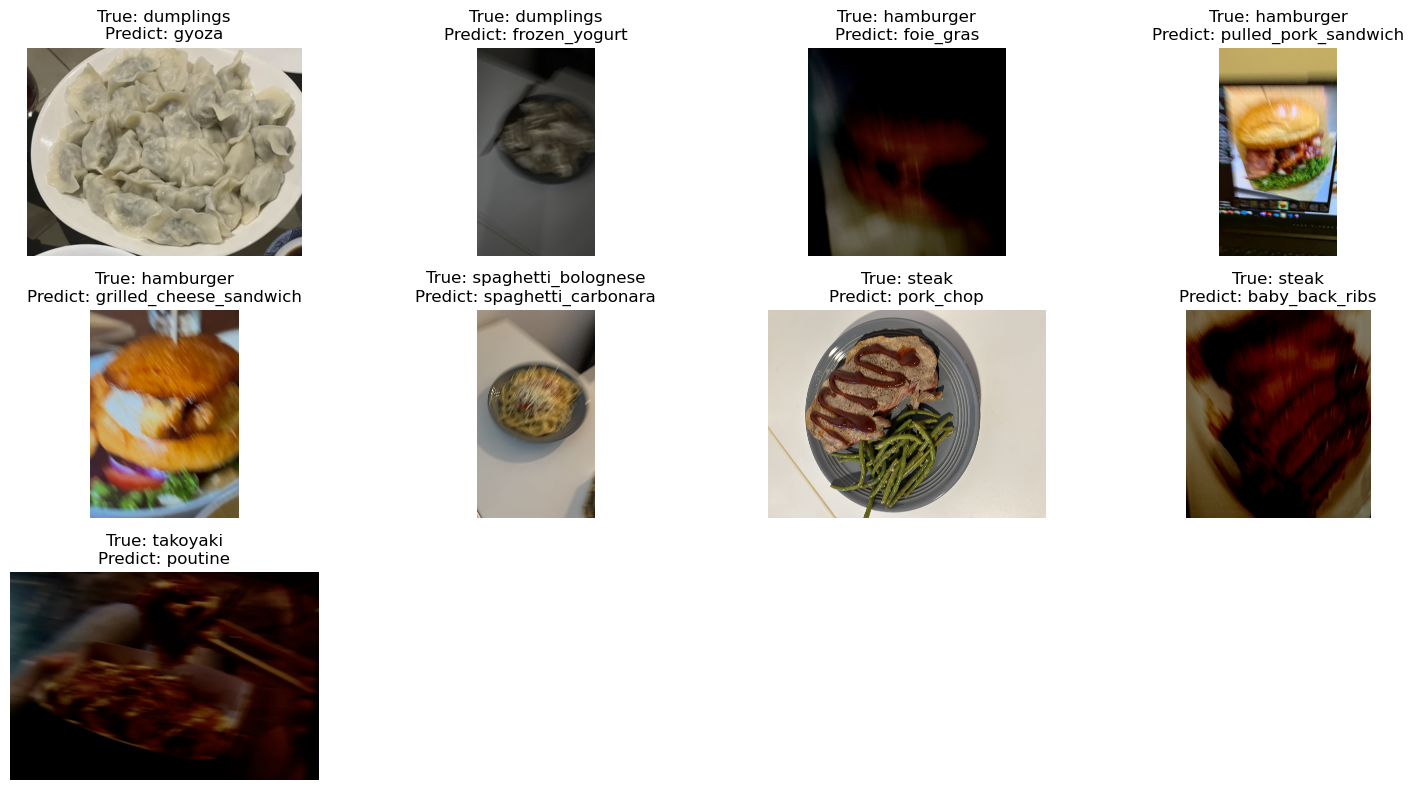

{'accuracy': 0.7954545454545454, 'f1_score': 0.8537878787878789}


In [2]:
dataset_path = './data/raw'
results = model.predict_folder(dataset_path)
plot.wrong_predictions(results, folder = dataset_path)
metrics = calculate_metrics(**results)
print(metrics)

### Part II - Individual Algorithm Evaluation

Process our collected data with the image processing algorithms. Use them as the input to the model. Find which individual algorithm performs best

In [3]:
from preprocessing.lowlight import gamma, CLAHE, SSRetinex
from preprocessing.deblurr import ssk, usm, swf
from preprocessing.downscaling import Lanczos, Lanczos_SAID, DPID
from project_utils import preprocess_folder

output_path = './data/preprocessed'

# Low-light
for func in [gamma, CLAHE, SSRetinex]:
    preprocess_folder(func, input_dir=dataset_path, output_dir=output_path)
    results = model.predict_folder(output_path)
    metrics = calculate_metrics(**results)
    print(f"Metrics for {func.__name__}: {metrics}")
    #plot.wrong_predictions(results, folder = output_path)
shutil.rmtree(output_path)

# Deblurring
for func in [ssk, usm, swf]:
    preprocess_folder(func, input_dir=dataset_path, output_dir=output_path)
    results = model.predict_folder(output_path)
    metrics = calculate_metrics(**results)
    print(f"Metrics for {func.__name__}: {metrics}")
    #plot.wrong_predictions(results, folder = output_path)
shutil.rmtree(output_path)

# Downscaling
for func in [Lanczos, Lanczos_SAID, DPID]:
    preprocess_folder(func, input_dir=dataset_path, output_dir=output_path)
    results = model.predict_folder(output_path)
    metrics = calculate_metrics(**results)
    print(f"Metrics for {func.__name__}: {metrics}")
    #plot.wrong_predictions(results, folder = output_path)
shutil.rmtree(output_path)

Loaded 44 images from ./data/preprocessed
Predicted 44 images in 4.94s
Metrics for gamma: {'accuracy': 0.7727272727272727, 'f1_score': 0.8323002754820937}
Loaded 44 images from ./data/preprocessed
Predicted 44 images in 4.67s
Metrics for CLAHE: {'accuracy': 0.7272727272727273, 'f1_score': 0.790909090909091}
Loaded 44 images from ./data/preprocessed
Predicted 44 images in 4.68s
Metrics for SSRetinex: {'accuracy': 0.2727272727272727, 'f1_score': 0.32656926406926406}


c:\anaconda250618\envs\ece253_env\Lib\site-packages\sklearn\metrics\_classification.py:99: UserWarning: The number of unique classes is greater than 50% of the number of samples. `y` could represent a regression problem, not a classification problem.
  type_pred = type_of_target(y_pred, input_name="y_pred")
c:\anaconda250618\envs\ece253_env\Lib\site-packages\sklearn\utils\multiclass.py:79: UserWarning: The number of unique classes is greater than 50% of the number of samples. `y` could represent a regression problem, not a classification problem.
  ys_types = set(type_of_target(x) for x in ys)
c:\anaconda250618\envs\ece253_env\Lib\site-packages\sklearn\metrics\_classification.py:99: UserWarning: The number of unique classes is greater than 50% of the number of samples. `y` could represent a regression problem, not a classification problem.
  type_pred = type_of_target(y_pred, input_name="y_pred")
c:\anaconda250618\envs\ece253_env\Lib\site-packages\sklearn\utils\multiclass.py:79: UserWa

Loaded 44 images from ./data/preprocessed
Predicted 44 images in 5.22s
Metrics for ssk: {'accuracy': 0.8181818181818182, 'f1_score': 0.8742424242424243}
Loaded 44 images from ./data/preprocessed
Predicted 44 images in 5.18s
Metrics for usm: {'accuracy': 0.7727272727272727, 'f1_score': 0.8415501165501168}
Loaded 44 images from ./data/preprocessed
Predicted 44 images in 4.53s
Metrics for swf: {'accuracy': 0.75, 'f1_score': 0.8060606060606061}
Loaded 44 images from ./data/preprocessed
Predicted 44 images in 1.51s
Metrics for Lanczos: {'accuracy': 0.75, 'f1_score': 0.8201790633608816}
[INFO] Loading SAID model 'SAID_Lanczos' from c:\Users\Austin Chen\Desktop\UCSD\2025_Fall\ECE253\Project\ECE253-food-classification\src\preprocessing\..\..\SAID\pretrained_models\SAID_Lanczos.pth


c:\Users\Austin Chen\Desktop\UCSD\2025_Fall\ECE253\Project\ECE253-food-classification\./src\preprocessing\downscaling.py:77: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  ck

Loaded 44 images from ./data/preprocessed
Predicted 44 images in 1.34s
Metrics for Lanczos_SAID: {'accuracy': 0.6818181818181818, 'f1_score': 0.7371212121212122}
Loaded 44 images from ./data/preprocessed
Predicted 44 images in 1.41s
Metrics for DPID: {'accuracy': 0.75, 'f1_score': 0.8151515151515152}


### Part III - Combination Search

Find the best low-light - deblur - downscale combination

In [5]:

# find the best low-light - deblur - downscale combination

output_path = './data/preprocessed'
best_metrics = None
best_combination = None

for func1 in [gamma, CLAHE, SSRetinex]:
    for func2 in [ssk, usm, swf]:
        for func3 in [Lanczos, Lanczos_SAID, DPID]:
            preprocess_folder(func1, input_dir=dataset_path, output_dir=output_path)
            preprocess_folder(func2, input_dir=output_path, output_dir=output_path)
            preprocess_folder(func3, input_dir=output_path, output_dir=output_path)
            results = model.predict_folder(output_path)
            metrics = calculate_metrics(**results)
            print(f"Metrics for {func1.__name__} + {func2.__name__} + {func3.__name__}: {metrics}")
            #plot.wrong_predictions(results, folder = output_path)
            shutil.rmtree(output_path)

            if best_metrics is None or metrics['accuracy'] > best_metrics['accuracy']:
                best_metrics = metrics
                best_combination = (func1.__name__, func2.__name__, func3.__name__)

print(f"Best combination: {best_combination} with metrics: {best_metrics}")

Loaded 44 images from ./data/preprocessed
Predicted 44 images in 1.48s
Metrics for gamma + ssk + Lanczos: {'accuracy': 0.6363636363636364, 'f1_score': 0.7420306965761512}


c:\anaconda250618\envs\ece253_env\Lib\site-packages\sklearn\metrics\_classification.py:99: UserWarning: The number of unique classes is greater than 50% of the number of samples. `y` could represent a regression problem, not a classification problem.
  type_pred = type_of_target(y_pred, input_name="y_pred")
c:\anaconda250618\envs\ece253_env\Lib\site-packages\sklearn\utils\multiclass.py:79: UserWarning: The number of unique classes is greater than 50% of the number of samples. `y` could represent a regression problem, not a classification problem.
  ys_types = set(type_of_target(x) for x in ys)
c:\anaconda250618\envs\ece253_env\Lib\site-packages\sklearn\metrics\_classification.py:99: UserWarning: The number of unique classes is greater than 50% of the number of samples. `y` could represent a regression problem, not a classification problem.
  type_pred = type_of_target(y_pred, input_name="y_pred")
c:\anaconda250618\envs\ece253_env\Lib\site-packages\sklearn\utils\multiclass.py:79: UserWa

Loaded 44 images from ./data/preprocessed
Predicted 44 images in 1.43s
Metrics for gamma + ssk + Lanczos_SAID: {'accuracy': 0.6590909090909091, 'f1_score': 0.7393939393939394}


c:\anaconda250618\envs\ece253_env\Lib\site-packages\sklearn\metrics\_classification.py:99: UserWarning: The number of unique classes is greater than 50% of the number of samples. `y` could represent a regression problem, not a classification problem.
  type_pred = type_of_target(y_pred, input_name="y_pred")
c:\anaconda250618\envs\ece253_env\Lib\site-packages\sklearn\utils\multiclass.py:79: UserWarning: The number of unique classes is greater than 50% of the number of samples. `y` could represent a regression problem, not a classification problem.
  ys_types = set(type_of_target(x) for x in ys)
c:\anaconda250618\envs\ece253_env\Lib\site-packages\sklearn\metrics\_classification.py:99: UserWarning: The number of unique classes is greater than 50% of the number of samples. `y` could represent a regression problem, not a classification problem.
  type_pred = type_of_target(y_pred, input_name="y_pred")
c:\anaconda250618\envs\ece253_env\Lib\site-packages\sklearn\utils\multiclass.py:79: UserWa

Loaded 44 images from ./data/preprocessed
Predicted 44 images in 1.55s
Metrics for gamma + ssk + DPID: {'accuracy': 0.7272727272727273, 'f1_score': 0.8045454545454547}
Loaded 44 images from ./data/preprocessed
Predicted 44 images in 1.55s
Metrics for gamma + usm + Lanczos: {'accuracy': 0.6136363636363636, 'f1_score': 0.7193034238488782}


...

Loaded 44 images from ./data/preprocessed
Predicted 44 images in 1.45s
Metrics for CLAHE + swf + Lanczos_SAID: {'accuracy': 0.6363636363636364, 'f1_score': 0.7461498097861735}


c:\anaconda250618\envs\ece253_env\Lib\site-packages\sklearn\metrics\_classification.py:99: UserWarning: The number of unique classes is greater than 50% of the number of samples. `y` could represent a regression problem, not a classification problem.
  type_pred = type_of_target(y_pred, input_name="y_pred")
c:\anaconda250618\envs\ece253_env\Lib\site-packages\sklearn\utils\multiclass.py:79: UserWarning: The number of unique classes is greater than 50% of the number of samples. `y` could represent a regression problem, not a classification problem.
  ys_types = set(type_of_target(x) for x in ys)
c:\anaconda250618\envs\ece253_env\Lib\site-packages\sklearn\metrics\_classification.py:99: UserWarning: The number of unique classes is greater than 50% of the number of samples. `y` could represent a regression problem, not a classification problem.
  type_pred = type_of_target(y_pred, input_name="y_pred")
c:\anaconda250618\envs\ece253_env\Lib\site-packages\sklearn\utils\multiclass.py:79: UserWa

Loaded 44 images from ./data/preprocessed
Predicted 44 images in 1.55s
Metrics for CLAHE + swf + DPID: {'accuracy': 0.7272727272727273, 'f1_score': 0.8036907536907538}
Loaded 44 images from ./data/preprocessed
Predicted 44 images in 1.58s
Metrics for SSRetinex + ssk + Lanczos: {'accuracy': 0.1590909090909091, 'f1_score': 0.2159090909090909}


c:\anaconda250618\envs\ece253_env\Lib\site-packages\sklearn\metrics\_classification.py:99: UserWarning: The number of unique classes is greater than 50% of the number of samples. `y` could represent a regression problem, not a classification problem.
  type_pred = type_of_target(y_pred, input_name="y_pred")
c:\anaconda250618\envs\ece253_env\Lib\site-packages\sklearn\utils\multiclass.py:79: UserWarning: The number of unique classes is greater than 50% of the number of samples. `y` could represent a regression problem, not a classification problem.
  ys_types = set(type_of_target(x) for x in ys)
c:\anaconda250618\envs\ece253_env\Lib\site-packages\sklearn\metrics\_classification.py:99: UserWarning: The number of unique classes is greater than 50% of the number of samples. `y` could represent a regression problem, not a classification problem.
  type_pred = type_of_target(y_pred, input_name="y_pred")
c:\anaconda250618\envs\ece253_env\Lib\site-packages\sklearn\utils\multiclass.py:79: UserWa

Loaded 44 images from ./data/preprocessed
Predicted 44 images in 1.47s
Metrics for SSRetinex + ssk + Lanczos_SAID: {'accuracy': 0.22727272727272727, 'f1_score': 0.2923853923853924}
Loaded 44 images from ./data/preprocessed
Predicted 44 images in 1.48s
Metrics for SSRetinex + ssk + DPID: {'accuracy': 0.25, 'f1_score': 0.3087121212121212}
Loaded 44 images from ./data/preprocessed
Predicted 44 images in 1.47s
Metrics for SSRetinex + usm + Lanczos: {'accuracy': 0.1590909090909091, 'f1_score': 0.2125}
Loaded 44 images from ./data/preprocessed
Predicted 44 images in 1.51s
Metrics for SSRetinex + usm + Lanczos_SAID: {'accuracy': 0.20454545454545456, 'f1_score': 0.26209415584415585}
Loaded 44 images from ./data/preprocessed
Predicted 44 images in 1.55s
Metrics for SSRetinex + usm + DPID: {'accuracy': 0.25, 'f1_score': 0.3087121212121212}
Loaded 44 images from ./data/preprocessed
Predicted 44 images in 1.42s
Metrics for SSRetinex + swf + Lanczos: {'accuracy': 0.22727272727272727, 'f1_score': 0.

### Part IV - Model Fine-Tuning

In [ ]:
from models.trainer import fine_tune

fine_tune(
    model_wrapper=model,
    data_dir=dataset_path,
    val_ratio=0.3,
    epochs=20,
    batch_size=4,
    lr=5e-5
)